In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

state_farm_distracted_driver_detection_path = kagglehub.competition_download('state-farm-distracted-driver-detection')

print('Data source import complete.')


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('state-farm-distracted-driver-detection')

print("Path to competition files:", path)

In [ ]:
!nvidia-smi

In [ ]:
# INSTALL LIBRARIES

!pip install -q timm

In [ ]:
# IMPORTS

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

In [ ]:
import torch
print(torch.cuda.device_count())

2


In [ ]:
# SEED + DEVICE

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
# DATASET PATH

DATASET_PATH = "/kaggle/input/competitions/state-farm-distracted-driver-detection/imgs/train"

In [ ]:
# TRANSFORMS

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# LOAD DATASET

dataset = ImageFolder(DATASET_PATH)

class_names = dataset.classes

print(class_names)
print("Dataset Size:", len(dataset))

['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Dataset Size: 22424


In [ ]:
indices = np.arange(len(dataset))
labels = [y for _, y in dataset.samples]

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=SEED,
    stratify=labels
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

In [ ]:
train_dataset_full = ImageFolder(DATASET_PATH, transform=train_transform)
val_dataset_full = ImageFolder(DATASET_PATH, transform=val_transform)
test_dataset_full = ImageFolder(DATASET_PATH, transform=val_transform)

In [ ]:
train_dataset = Subset(train_dataset_full, train_idx)
val_dataset = Subset(val_dataset_full, val_idx)
test_dataset = Subset(test_dataset_full, test_idx)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 15696
Val: 3364
Test: 3364


In [ ]:
# DATALOADERS

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

## RESNET50

In [ ]:
#  RESNET50 MODEL

model = timm.create_model(
    "resnet50",
    pretrained=True,
    num_classes=10
)

model = nn.DataParallel(model)
model = model.to(device)
print(model)

In [ ]:
#UNFREEZE MODEL (RESNET50)

for param in model.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

### Training

In [ ]:
# TRAINING (RESNET50)

fine_tune_epochs = 10

best_val_acc = 0

for epoch in range(fine_tune_epochs):

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    model.train()

    train_preds = []
    train_labels = []

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()

    val_preds = []
    val_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step()

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "resnet50_best.pth")

        print("Best model saved")


Epoch 1/10


100%|██████████| 491/491 [01:59<00:00,  4.12it/s]


Train Accuracy: 0.5853083588175332
Validation Accuracy: 0.9253864447086801
Best model saved

Epoch 2/10


  8%|▊         | 40/491 [00:10<01:45,  4.29it/s]

Train Accuracy: 0.9301095820591233
Validation Accuracy: 0.976218787158145
Best model saved

Epoch 3/10


...

Train Accuracy: 0.9920998980632009
Validation Accuracy: 0.9943519619500595

Epoch 9/10


100%|██████████| 491/491 [01:58<00:00,  4.13it/s]


Train Accuracy: 0.9945208970438328
Validation Accuracy: 0.9946492271105827

Epoch 10/10


100%|██████████| 491/491 [01:59<00:00,  4.11it/s]


Train Accuracy: 0.99394750254842
Validation Accuracy: 0.995243757431629
Best model saved


### Testing

In [ ]:
# TEST EVALUATION (RESNET50)

model.load_state_dict(torch.load("resnet50_best.pth"))

model.eval()

test_preds_resnet = []
test_labels_resnet = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        test_preds_resnet.extend(preds.cpu().numpy())
        test_labels_resnet.extend(labels.numpy())

accuracy_resnet = accuracy_score(test_labels_resnet, test_preds_resnet)

precision_resnet = precision_score(
    test_labels_resnet,
    test_preds_resnet,
    average='macro'
)

recall_resnet = recall_score(
    test_labels_resnet,
    test_preds_resnet,
    average='macro'
)

f1_resnet = f1_score(
    test_labels_resnet,
    test_preds_resnet,
    average='macro'
)



print("Accuracy :", accuracy_resnet)
print("Precision:", precision_resnet)
print("Recall   :", recall_resnet)
print("F1 Score :", f1_resnet)


100%|██████████| 106/106 [00:12<00:00,  8.20it/s]

Accuracy : 0.9946492271105827
Precision: 0.9945951762973365
Recall   : 0.9946069736287878
F1 Score : 0.9945980085028492


## SWIN TRANSFORMER


In [ ]:
# SWIN TRANSFORMER MODEL

model_2 = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=10
)
model_2 = nn.DataParallel(model_2)
model_2 = model_2.to(device)

print(model_2)

In [ ]:

for param in model_2.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    model_2.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=10,
    eta_min=1e-6)

### Training

In [ ]:
# TRAINING (SWIN)

fine_tune_epochs = 10

best_val_acc = 0

for epoch in range(fine_tune_epochs):

    print(f"\nEpoch {epoch+1}/{fine_tune_epochs}")

    model_2.train()

    train_preds = []
    train_labels = []

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_2(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    model_2.eval()

    val_preds = []
    val_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            outputs = model_2(images)

            preds = torch.argmax(outputs, dim=1)

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    scheduler.step()

    print("Train Accuracy:", train_acc)
    print("Validation Accuracy:", val_acc)

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model_2.state_dict(), "swin_best.pth")

        print("Best model saved")


Epoch 1/10


100%|██████████| 491/491 [02:23<00:00,  3.42it/s]


Train Accuracy: 0.9743246687054027
Validation Accuracy: 0.9797859690844233
Best model saved

Epoch 2/10


100%|██████████| 491/491 [02:22<00:00,  3.45it/s]


Train Accuracy: 0.9837538226299695
Validation Accuracy: 0.9836504161712247
Best model saved

Epoch 3/10


...

Train Accuracy: 0.9992354740061162
Validation Accuracy: 0.9964328180737217
Best model saved

Epoch 9/10


100%|██████████| 491/491 [02:22<00:00,  3.44it/s]


Train Accuracy: 0.9991717635066258
Validation Accuracy: 0.9973246135552913
Best model saved

Epoch 10/10


100%|██████████| 491/491 [02:22<00:00,  3.44it/s]


Train Accuracy: 0.9995540265035678
Validation Accuracy: 0.9976218787158145
Best model saved


### Testing

In [ ]:
# TEST EVALUATION (SWIN)

model_2.load_state_dict(torch.load("swin_best.pth"))

model_2.eval()

test_preds_swin = []
test_labels_swin = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model_2(images)

        preds = torch.argmax(outputs, dim=1)

        test_preds_swin.extend(preds.cpu().numpy())
        test_labels_swin.extend(labels.numpy())

accuracy_swin = accuracy_score(test_labels, test_preds)

precision_swin = precision_score(
    test_labels_swin,
    test_preds_swin,
    average='macro'
)

recall_swin = recall_score(
    test_labels_swin,
    test_preds_swin,
    average='macro'
)

f1_swin = f1_score(
    test_labels_swin,
    test_preds_swin,
    average='macro'
)



print("Accuracy :", accuracy_swin)
print("Precision:", precision_swin)
print("Recall   :", recall_swin)
print("F1 Score :", f1_swin)


100%|██████████| 106/106 [00:14<00:00,  7.56it/s]

Accuracy : 0.9956896551724138
Precision: 0.9967825050692325
Recall   : 0.9967059363225769
F1 Score : 0.9967357997243868


In [ ]:
# EXPERIMENTAL SETUP

print('Hardware:', torch.cuda.get_device_name(0))
print('PyTorch Version:', torch.__version__)
print('Random Seed: 42')
print('Train Size:', len(train_dataset))
print('Val Size  :', len(val_dataset))
print('Test Size :', len(test_dataset))

Hardware: Tesla T4
PyTorch Version: 2.10.0+cu128
Random Seed: 42
Train Size: 15696
Val Size  : 3364
Test Size : 3364


In [ ]:
# PER-CLASS F1 - RESNET-50

print('=== ResNet-50 Per-Class Report ===')
print(classification_report(test_labels_resnet, test_preds_resnet, target_names=class_names))

=== ResNet-50 Per-Class Report ===
              precision    recall  f1-score   support

          c0       0.99      0.99      0.99       373
          c1       1.00      1.00      1.00       340
          c2       1.00      1.00      1.00       347
          c3       1.00      1.00      1.00       352
          c4       1.00      0.99      1.00       349
          c5       1.00      0.99      1.00       347
          c6       1.00      1.00      1.00       349
          c7       1.00      1.00      1.00       301
          c8       0.99      0.99      0.99       287
          c9       0.98      0.98      0.98       319

    accuracy                           0.99      3364
   macro avg       0.99      0.99      0.99      3364
weighted avg       0.99      0.99      0.99      3364



In [ ]:
# PER-CLASS F1 - SWIN TRANSFORMER

print('=== Swin Transformer Per-Class Report ===')
print(classification_report(test_labels_swin, test_preds_swin, target_names=class_names))

=== Swin Transformer Per-Class Report ===
              precision    recall  f1-score   support

          c0       0.99      0.99      0.99       373
          c1       1.00      1.00      1.00       340
          c2       1.00      1.00      1.00       347
          c3       1.00      1.00      1.00       352
          c4       1.00      1.00      1.00       349
          c5       1.00      1.00      1.00       347
          c6       0.99      1.00      1.00       349
          c7       1.00      1.00      1.00       301
          c8       1.00      0.99      0.99       287
          c9       0.98      1.00      0.99       319

    accuracy                           1.00      3364
   macro avg       1.00      1.00      1.00      3364
weighted avg       1.00      1.00      1.00      3364



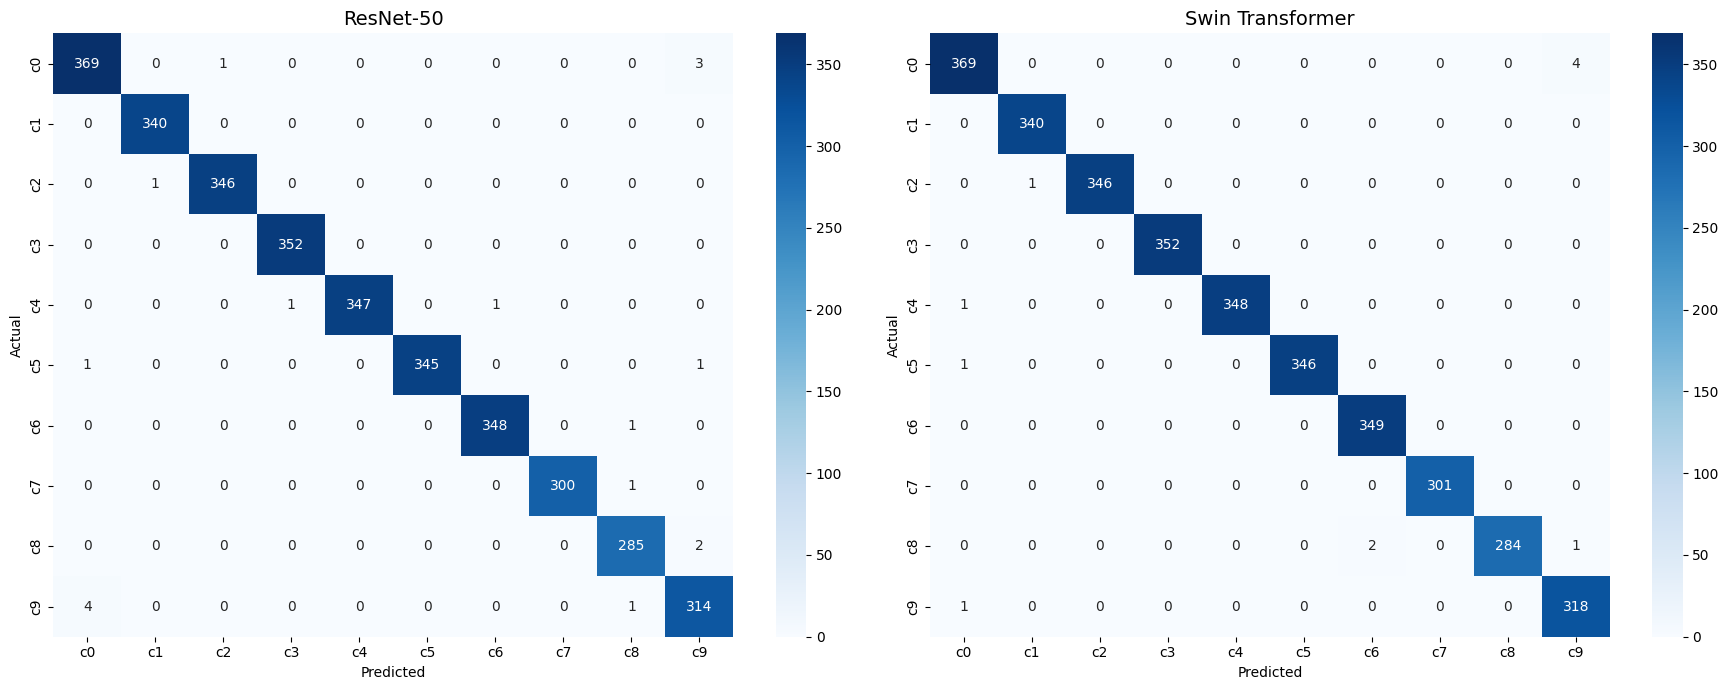

In [ ]:
# CONFUSION MATRICES - SIDE BY SIDE

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, preds, labels, title in zip(
    axes,
    [test_preds_resnet, test_preds_swin],
    [test_labels_resnet, test_labels_swin],
    ['ResNet-50', 'Swin Transformer']
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        ax=ax,
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# PARAMETER COUNT

resnet_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
swin_params   = sum(p.numel() for p in model_2.parameters() if p.requires_grad)

print(f'ResNet-50 Parameters : {resnet_params:,}')
print(f'Swin-Tiny Parameters : {swin_params:,}')

ResNet-50 Parameters : 23,528,522
Swin-Tiny Parameters : 27,527,044


In [ ]:
# INFERENCE TIME

import time

def measure_inference_time(model, loader, device):
    model.eval()
    start = time.time()
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            _ = model(images)
    return round(time.time() - start, 2)

resnet_inference = measure_inference_time(model,   test_loader, device)
swin_inference   = measure_inference_time(model_2, test_loader, device)

print(f'ResNet-50 Inference Time : {resnet_inference} sec')
print(f'Swin-Tiny Inference Time : {swin_inference} sec')

ResNet-50 Inference Time : 12.33 sec
Swin-Tiny Inference Time : 14.04 sec


In [ ]:
# FINAL SUMMARY TABLE

print('=' * 65)
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('=' * 65)
print(f"{'ResNet-50':<20} {accuracy_resnet:>10.4f} {precision_resnet:>10.4f} {recall_resnet:>10.4f} {f1_resnet:>10.4f}")
print(f"{'Swin-Tiny':<20} {accuracy_swin:>10.4f} {precision_swin:>10.4f} {recall_swin:>10.4f} {f1_swin:>10.4f}")
print('=' * 65)
print()
print('=' * 55)
print(f"{'Model':<20} {'Params':>12} {'Inference (s)':>15}")
print('=' * 55)
print(f"{'ResNet-50':<20} {resnet_params:>12,} {resnet_inference:>15}")
print(f"{'Swin-Tiny':<20} {swin_params:>12,} {swin_inference:>15}")
print('=' * 55)

Model                  Accuracy  Precision     Recall         F1
ResNet-50                0.9946     0.9946     0.9946     0.9946
Swin-Tiny                0.9957     0.9968     0.9967     0.9967

Model                      Params   Inference (s)
ResNet-50              23,528,522           12.33
Swin-Tiny              27,527,044           14.04
